In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import os
import pyshark

Versions for libraries imported 

In [2]:
print(np.__version__)
print(matplotlib.__version__)
print(pd.__version__)


1.26.4
3.10.6
2.3.3


In [3]:


Experiment1Folder="VehicleExperiment_Output"
Experiment2Folder="SpeedExperiment_Output"
Experiment3Folder="PERExperiment_Output"


QUICDataFolder="QUIC"
TCPDataFolder="TCP"
CombinedDataOutputFolder='CombinedData'
QUICCSVFiles=[]
TCPCSVFiles=[]
NumOfTrials=50
NumOfIndexs=7
NumOfPERValues=6
NumOfVehicles=6
NumOfSpeedValues=7
#Constants
VEHICLEINDEX=0
SPEEDINDEX=1
PERINDEX=2
AVGDELAYINDEX=3
P95INDEX=4
JITTERINDEX=5
GOODPUTINDEX=6

In [667]:
try:
    os.mkdir(CombinedDataOutputFolder)
except:
    print("error making folder")

error making folder


In [668]:
def GetCSVFiles(QUICPath,TCPPath):
    try:
        QUICCSVFiles=os.listdir(QUICPath)
        TCPCSVFiles=os.listdir(TCPPath)

        return QUICCSVFiles,TCPCSVFiles
    except:
        print("couldn't open folder")
        return 0,0

In [669]:
#print(os.listdir(Experiment1Folder+"/"+QUICDataFolder))


In [670]:
def PrintStatistics(TCPArr,QUICArr):
    print(np.shape(QUICArr))
    print("QUIC stats")
    print(np.std(QUICArr,axis=(0)))
    print("TCP stats")
    print(np.std(TCPArr,axis=(0)))

In [671]:
def GetAverageandMedianArrays(ROWS,QUICPath,TCPPath):
    QUICCSVFiles, TCPCSVFiles=GetCSVFiles(QUICPath,TCPPath)
    QUICarray=np.zeros(shape=(NumOfTrials,ROWS,NumOfIndexs))
    TCParray=np.zeros(shape=(NumOfTrials,ROWS,NumOfIndexs))
    BadFiles=[]
    for i in range(0,NumOfTrials):
        Temp=np.loadtxt(QUICPath+"/"+QUICCSVFiles[i],delimiter=',',dtype=float,skiprows=1)
        Temp2=np.loadtxt(TCPPath+"/"+TCPCSVFiles[i],delimiter=',',dtype=float,skiprows=1)
        if (np.shape(Temp)[0]==ROWS and np.shape(Temp2)[0]==ROWS):
            QUICarray[i]=np.loadtxt(QUICPath+"/"+QUICCSVFiles[i],delimiter=',',dtype=float,skiprows=1)
            TCParray[i]=np.loadtxt(TCPPath+"/"+TCPCSVFiles[i],delimiter=',',dtype=float,skiprows=1)
        else:
            BadFiles.append(i)
    temp=np.zeros(shape=(NumOfTrials-len(BadFiles),ROWS,NumOfIndexs))
    temp2=np.zeros(shape=(NumOfTrials-len(BadFiles),ROWS,NumOfIndexs))
    print(len(BadFiles))
    index=0
    badfileindex=0
    if (len(BadFiles)!=0):
     for i in range(0,NumOfTrials):
        if (i==BadFiles[badfileindex]):
            #index=index+1
            badfileindex=badfileindex+1
            if (badfileindex>=len(BadFiles)):
                badfileindex=0
        else:
            temp[index]=QUICarray[i]
            temp2[index]=TCParray[i]
            index=index+1
     QUICarray=temp
     TCParray=temp2
    PrintStatistics(TCParray[0:,0:,AVGDELAYINDEX],QUICarray[0:,0:,AVGDELAYINDEX])
    AverageQUICResults=np.zeros(shape=(ROWS,NumOfIndexs))
    AverageTCPResults=np.zeros(shape=(ROWS,NumOfIndexs))
    MedianQUICResults=np.zeros(shape=(ROWS,NumOfIndexs))
    MedianTCPResults=np.zeros(shape=(ROWS,NumOfIndexs))
    for i in range(0,NumOfIndexs):
        for j in range(0,ROWS):
            AverageQUICResults[j,i]=np.average(QUICarray[0:,j,i])
            AverageTCPResults[j,i]=np.average(TCParray[0:,j,i])
            MedianQUICResults[j,i]=np.median(QUICarray[0:,j,i])
            MedianTCPResults[j,i]=np.median(TCParray[0:,j,i])
    return AverageQUICResults,AverageTCPResults,MedianQUICResults,MedianTCPResults

In [672]:
AverageQUICResults,AverageTCPResults,MedianQUICResults,MedianTCPResults=GetAverageandMedianArrays(NumOfPERValues,Experiment3Folder+"/"+QUICDataFolder, Experiment3Folder+"/"+TCPDataFolder)

4
(46, 6)
QUIC stats
[ 1.83549018  8.46786009 27.06593761 55.31677895 54.8410349  46.65584461]
TCP stats
[ 8.93666932 10.02207798 12.40138334 28.44985478 31.6342398  18.42434982]


In [673]:
def PlotQUICVsTCP(QUICArray,TCPArray,Title,XLabel,YLabel):
    plt.plot(QUICArray[0:,0],QUICArray[0:,1],label="QUIC")
    plt.plot(TCPArray[0:,0],TCPArray[0:,1],label="TCP")
    plt.legend()
    plt.xlabel(XLabel)
    plt.ylabel(YLabel)
    plt.title(Title)
    plt.show()

In [674]:
CombinedFileName="CombinedAverageExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,AverageQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,AverageTCPResults,delimiter=',')


Average results
[  8.75168587  12.34461935  26.41803239 163.46869565 252.5710413
 134.67168261]
[ 35.87707609  41.14114783  54.63695    207.08832609 234.25506522
  66.64599348]


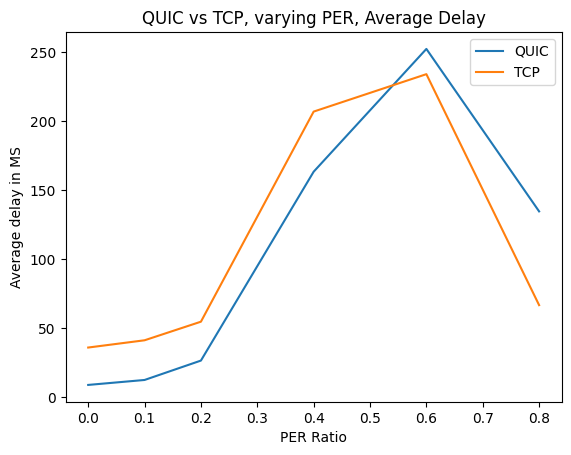

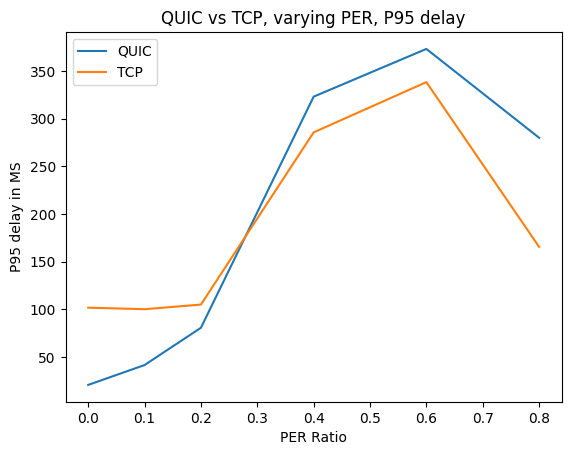

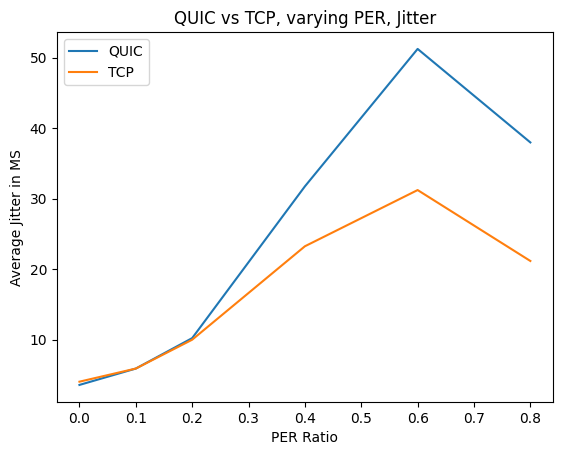

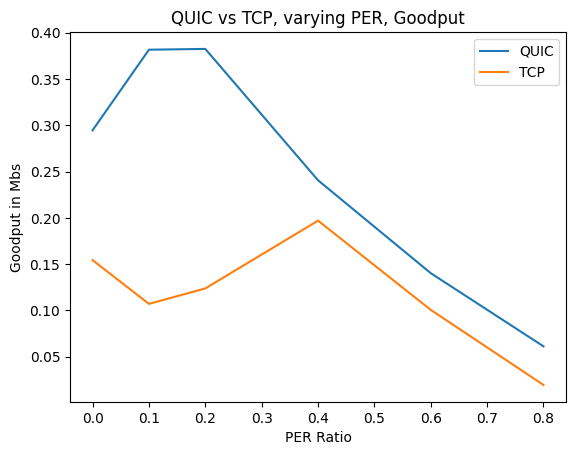

In [675]:
print("Average results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,AVGDELAYINDEX))

print(AvgDelayArrayQUIC[0:,1])
print(AvgDelayArrayTCP[0:,1])



PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, varying PER, Average Delay","PER Ratio","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, varying PER, P95 delay","PER Ratio","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, varying PER, Jitter","PER Ratio","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, varying PER, Goodput","PER Ratio","Goodput in Mbs")





In [676]:
print("Averages, QUIC VS TCP")
print(AvgDelayArrayQUIC[0:,1])
print(AvgDelayArrayTCP[0:,1])
print("P95, QUIC VS TCP")
print("QUIC: ",P95ArrayQUIC[0:,1])
print("TCP: ",P95ArrayTCP[0:,1])
print("MAX, QUIC VS TCP")
print(np.max(GoodputArrayQUIC[0:,1]))
print(np.max(GoodputArrayTCP[0:,1]))
print("MIN, QUIC VS TCP")

print(np.min(GoodputArrayQUIC[0:,1]))
print(np.min(GoodputArrayTCP[0:,1]))

Averages, QUIC VS TCP
[  8.75168587  12.34461935  26.41803239 163.46869565 252.5710413
 134.67168261]
[ 35.87707609  41.14114783  54.63695    207.08832609 234.25506522
  66.64599348]
P95, QUIC VS TCP
QUIC:  [ 20.4540913   41.34047261  80.49350217 323.24902174 373.38613043
 280.06417391]
TCP:  [101.60426522  99.98561957 104.8527     285.7385     338.50828261
 165.47757391]
MAX, QUIC VS TCP
0.38238150000000004
0.19694495652173916
MIN, QUIC VS TCP
0.06121819239130435
0.01955642391304348


In [677]:
CombinedFileName="CombinedMedianExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,MedianQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,MedianTCPResults,delimiter=',')

Median results


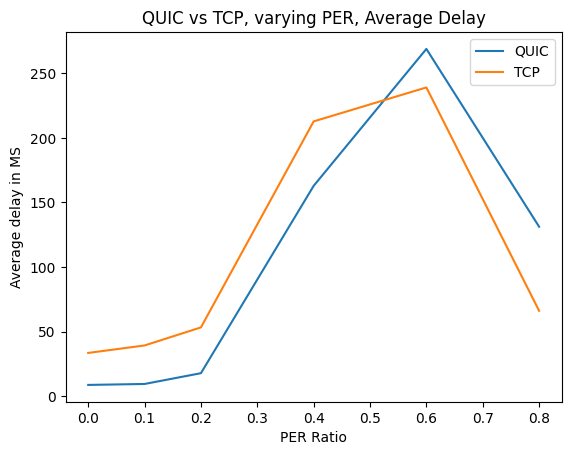

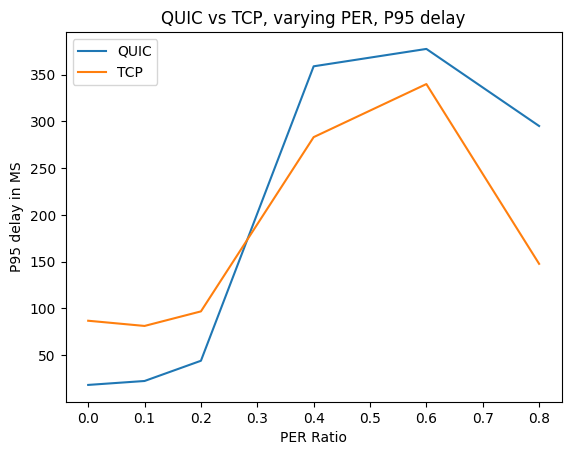

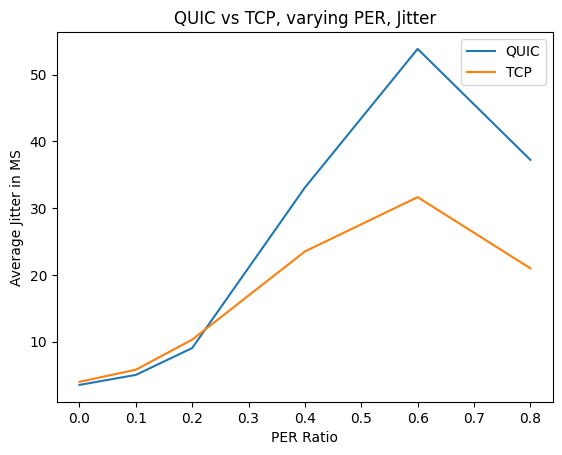

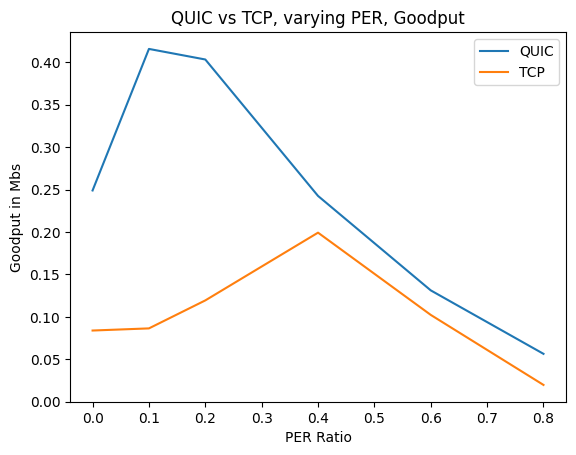

In [678]:
print("Median results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, varying PER, Average Delay","PER Ratio","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, varying PER, P95 delay","PER Ratio","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, varying PER, Jitter","PER Ratio","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=0,usecols=(PERINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, varying PER, Goodput","PER Ratio","Goodput in Mbs")


In [679]:
AverageQUICResults,AverageTCPResults,MedianQUICResults,MedianTCPResults=GetAverageandMedianArrays(NumOfVehicles,Experiment1Folder+"/"+QUICDataFolder, Experiment1Folder+"/"+TCPDataFolder)

2
(48, 6)
QUIC stats
[ 0.99116571  2.12040086  2.65975808 24.81211747 47.75946049 29.54397409]
TCP stats
[4.58806148e-03 6.41889372e+00 9.27662694e+00 8.64793906e+00
 8.69303956e+00 1.28181891e+01]


In [680]:
CombinedFileNameMedian="CombinedMedianExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,MedianQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,MedianTCPResults,delimiter=',')

CombinedFileNameAverage="CombinedAverageExperiment1.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,AverageQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,AverageTCPResults,delimiter=',')


Average results


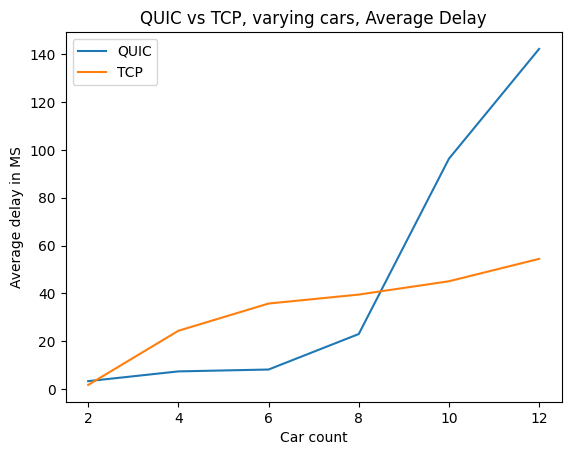

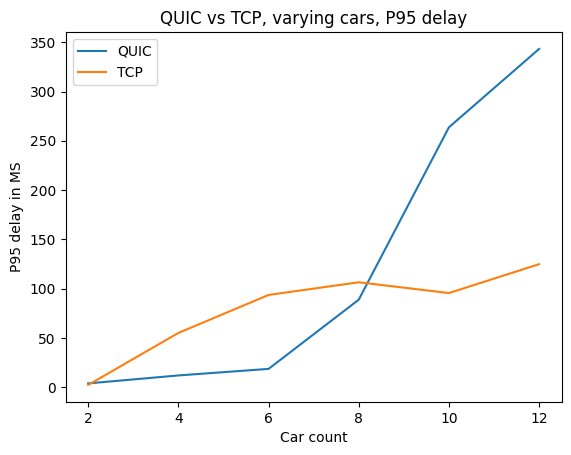

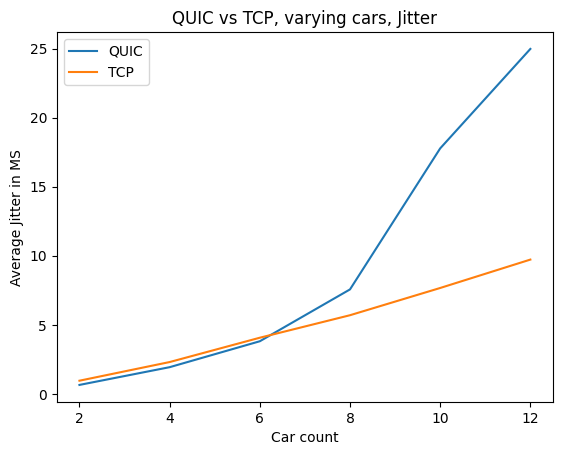

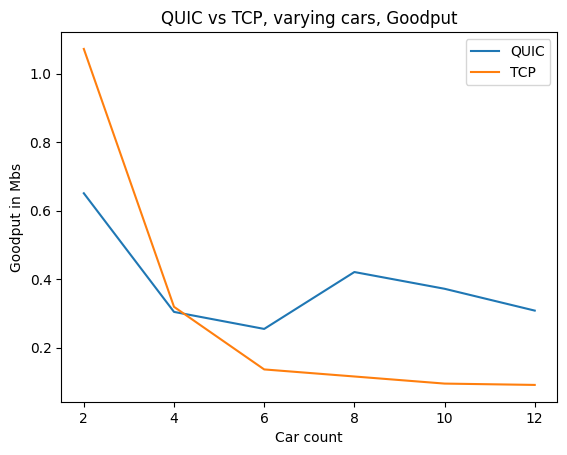

In [681]:
print("Average results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, varying cars, Average Delay","Car count","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, varying cars, P95 delay","Car count","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, varying cars, Jitter","Car count","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, varying cars, Goodput","Car count","Goodput in Mbs")

In [682]:
print("Averages, QUIC VS TCP")
print(AvgDelayArrayQUIC[0:,1])
print(AvgDelayArrayTCP[0:,1])
print("P95, QUIC VS TCP")
print("QUIC: ",P95ArrayQUIC[0:,1])
print("TCP: ",P95ArrayTCP[0:,1])

print("MAX, QUIC VS TCP")
print(np.max(GoodputArrayQUIC[0:,1]))
print(np.max(GoodputArrayTCP[0:,1]))
print("MIN, QUIC VS TCP")
print(np.min(GoodputArrayQUIC[0:,1]))
print(np.min(GoodputArrayTCP[0:,1]))

Averages, QUIC VS TCP
[  3.30864563   7.37771896   8.16227562  22.99900771  96.27999583
 142.19286667]
[ 1.72334208 24.36356063 35.74225625 39.4944     45.05766458 54.41961458]
P95, QUIC VS TCP
QUIC:  [  3.79788792  11.86817438  18.51707104  88.74337562 263.67581458
 343.21375   ]
TCP:  [  2.25163833  55.0144125   93.55016667 106.4217      95.47135208
 124.77621458]
MAX, QUIC VS TCP
0.6509463958333332
1.0723551041666668
MIN, QUIC VS TCP
0.25489193895833334
0.09140226041666666


Median results


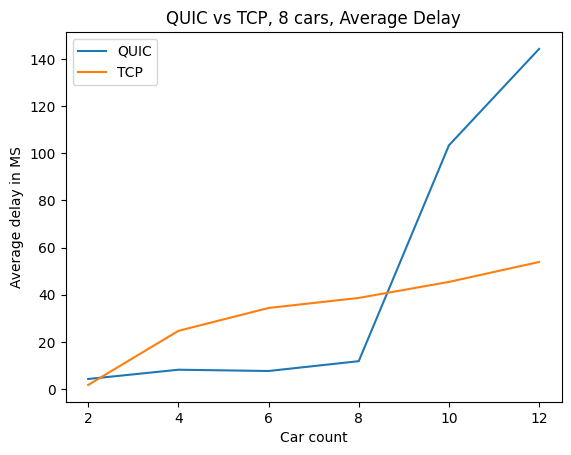

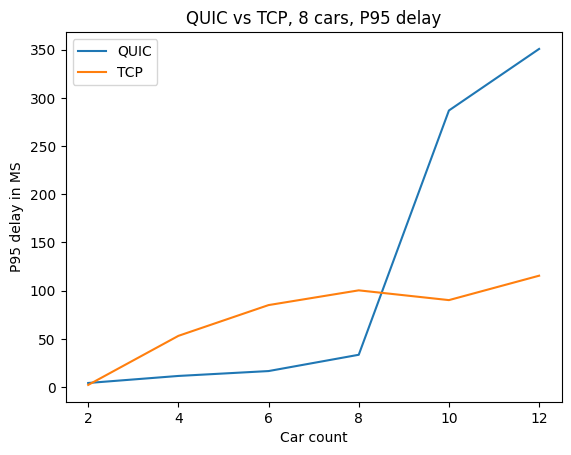

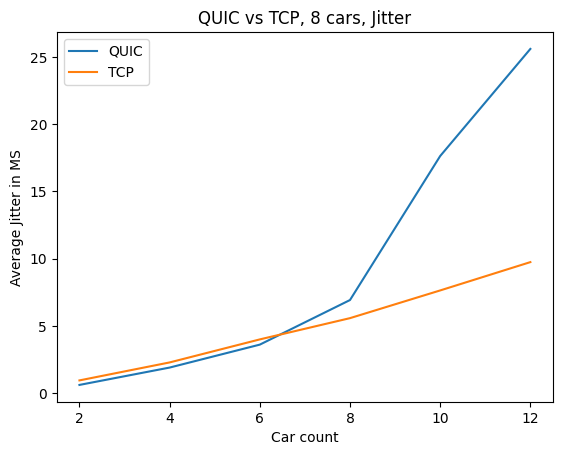

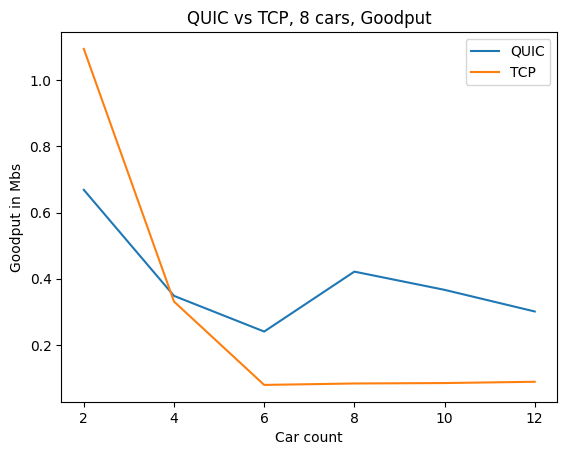

In [683]:
print("Median results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, 8 cars, Average Delay","Car count","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, 8 cars, P95 delay","Car count","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, 8 cars, Jitter","Car count","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(VEHICLEINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, 8 cars, Goodput","Car count","Goodput in Mbs")


Experiment 2 Speed test

In [684]:
AverageQUICResults,AverageTCPResults,MedianQUICResults,MedianTCPResults=GetAverageandMedianArrays(NumOfSpeedValues,Experiment2Folder+"/"+QUICDataFolder, Experiment2Folder+"/"+TCPDataFolder)
CombinedFileNameMedian="CombinedMedianExperiment2.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,MedianQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,MedianTCPResults,delimiter=',')

CombinedFileNameAverage="CombinedAverageExperiment2.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,AverageQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,AverageTCPResults,delimiter=',')

0
(50, 7)
QUIC stats
[1.66722824 2.57199799 5.31102508 2.35425365 2.85017307 1.89631356
 1.90986336]
TCP stats
[ 8.61147434  6.73162803  7.18539523 10.87091844  7.83814173  8.99226235
  9.31120651]


Speed Experiment
Average results


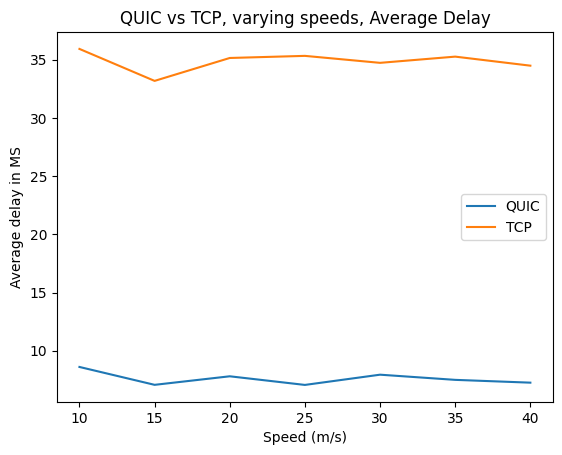

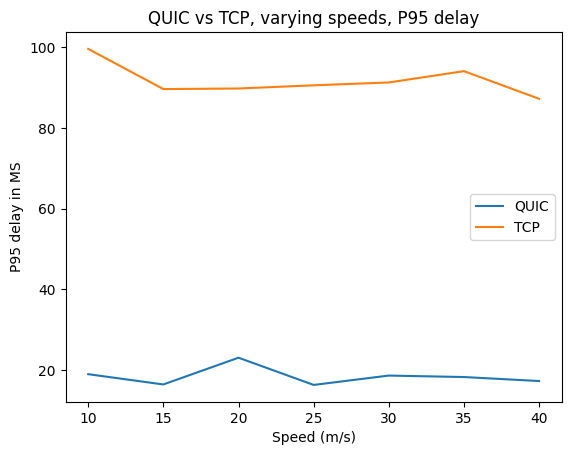

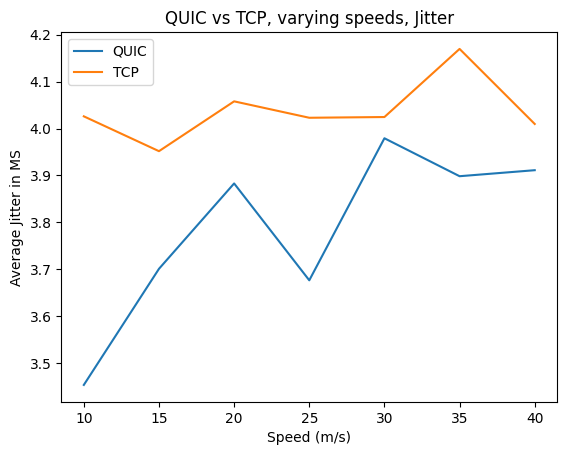

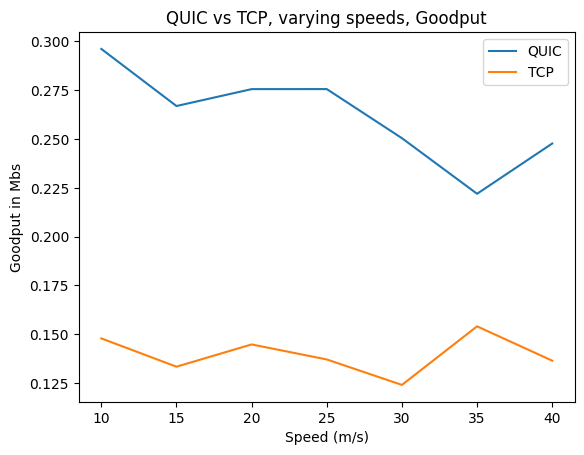

In [685]:
print("Speed Experiment")
print("Average results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, varying speeds, Average Delay","Speed (m/s)","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, varying speeds, P95 delay","Speed (m/s)","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, varying speeds, Jitter","Speed (m/s)","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameAverage,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, varying speeds, Goodput","Speed (m/s)","Goodput in Mbs")






In [686]:
print("Averages, QUIC VS TCP")
print("QUIC:",AvgDelayArrayQUIC[0:,1])
print("TCP:",AvgDelayArrayTCP[0:,1])
print("P95, QUIC VS TCP")
print("QUIC: ",P95ArrayQUIC[0:,1])
print("TCP: ",P95ArrayTCP[0:,1])

print("MAX")
print("QUIC",np.max(GoodputArrayQUIC[0:,1]))
print("TCP",np.max(GoodputArrayTCP[0:,1]))
print("MIN")
print("QUIC",np.min(GoodputArrayQUIC[0:,1]))
print("TCP",np.min(GoodputArrayTCP[0:,1]))

Averages, QUIC VS TCP
QUIC: [8.6114386 7.075576  7.8093692 7.068299  7.9472556 7.5030112 7.262693 ]
TCP: [35.926992 33.18138  35.149022 35.33031  34.731256 35.265068 34.488344]
P95, QUIC VS TCP
QUIC:  [18.982474  16.4339428 23.0638162 16.3183626 18.6363    18.271148
 17.2811502]
TCP:  [99.591252 89.636146 89.7856   90.57003  91.27854  94.082736 87.22654 ]
MAX
QUIC 0.29616734
TCP 0.15400995
MIN
QUIC 0.22194323599999996
TCP 0.12398574000000001


Median results


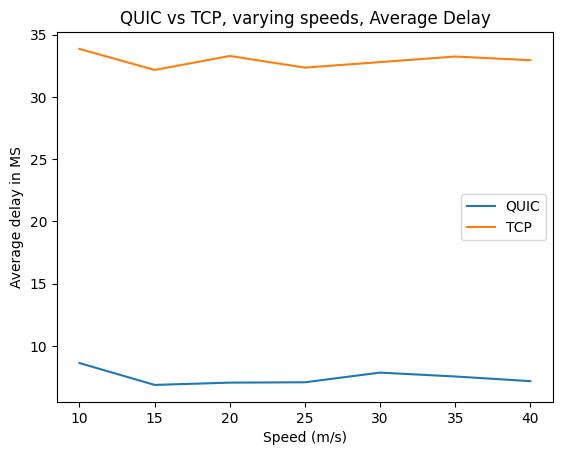

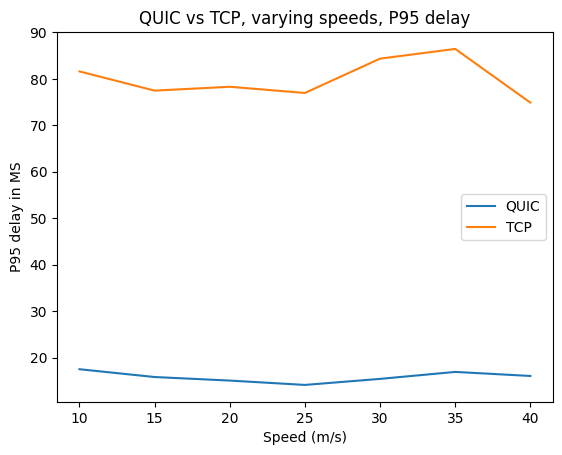

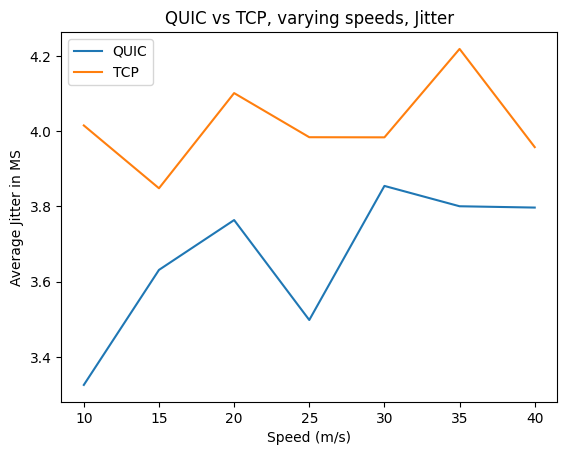

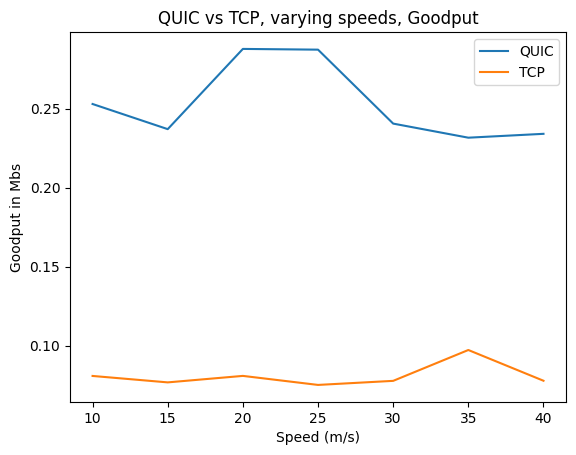

In [687]:
print("Median results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, varying speeds, Average Delay","Speed (m/s)","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, varying speeds, P95 delay","Speed (m/s)","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, varying speeds, Jitter","Speed (m/s)","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileNameMedian,delimiter=',',skiprows=0,usecols=(SPEEDINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, varying speeds, Goodput","Speed (m/s)","Goodput in Mbs")

In [13]:
PCAPFILEPATH='PCAP/'
print(os.listdir(PCAPFILEPATH))
CAP=pyshark.FileCapture('PCAP/1_goodput_QUIC-0-1.pcap')
#print(CAP[0])
CAP

['1_goodput_QUIC-0-1.pcap', '1_goodput_QUIC-2-1.pcap', '1_goodput_QUIC-1-1.pcap', '1_goodput_QUIC-3-1.pcap']


<FileCapture PCAP/1_goodput_QUIC-0-1.pcap>

In [14]:
print(CAP[0])

RuntimeError: This event loop is already running